In [1]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm

In [2]:
def Suceptibility_by_Level(CCN_ds, CDNC_da):
    """
    Compute OLS slope/intercept between CCN(radius, lev, time)
    and CDNC(lev, time) across 'time'.
    """
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

    OLS_slope, OLS_intercept = xr.apply_ufunc(
        Function.OLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    ODR_slope, ODR_intercept = xr.apply_ufunc(
        Function.TLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    Deming_slope, Deming_intercept = xr.apply_ufunc(
        Function.deming_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    PCA_slope, PCA_intercept = xr.apply_ufunc(
        Function.PCA_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_aligned),
        input_core_dims=[['time'], ['time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )

    ds_out = xr.Dataset(
        data_vars={
            'OLS slope': (('radius', 'lev'), OLS_slope.data),
            'OLS intercept': (('radius', 'lev'), OLS_intercept.data),
            'ODR slope': (('radius', 'lev'), ODR_slope.data),
            'ODR intercept': (('radius', 'lev'), ODR_intercept.data),
            'Deming slope': (('radius', 'lev'), Deming_slope.data),
            'Deming intercept': (('radius', 'lev'), Deming_intercept.data),
            'PCA slope': (('radius', 'lev'), PCA_slope.data),
            'PCA intercept': (('radius', 'lev'), PCA_intercept.data),

        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,

        }
    )
    ds_out2 = xr.Dataset(
        data_vars={
            'CCN': CCN_aligned,       # dims: (radius, lev, time)
            'CDNC': CDNC_aligned      # dims: (lev, time)
        },
        coords={
            'radius': CCN_aligned.radius,
            'lev': CCN_aligned.lev,
            'time': CCN_aligned.time
        }
    )

    return ds_out, ds_out2


In [3]:
def compute_allLev(CCN_ds, CDNC_da):
    """
    Compute OLS and TLS slope/intercept per radius,
    flattening across all levels and times.
    Returns a Dataset with variables: slope_OLS, intercept_OLS, slope_TLS, intercept_TLS
    """
    # Align CCN and CDNC over lev and time
    CCN_aligned, CDNC_aligned = xr.align(CCN_ds, CDNC_da)

    # Broadcast CDNC to match CCN dimensions
    CDNC_broadcast = CDNC_aligned.broadcast_like(CCN_aligned)

    # --- OLS ---
    slope_OLS, intercept_OLS = xr.apply_ufunc(
        Function.OLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )

    # --- TLS ---
    slope_TLS, intercept_TLS = xr.apply_ufunc(
        Function.TLS_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    
    # --- Deming ---
    slope_Deming, intercept_Deming = xr.apply_ufunc(
        Function.deming_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )
    # --- PCA ---
    slope_PCA, intercept_PCA = xr.apply_ufunc(
        Function.PCA_fit,
        np.log10(CCN_aligned),
        np.log10(CDNC_broadcast),
        input_core_dims=[['lev', 'time'], ['lev', 'time']],
        output_core_dims=[[], []],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float, float],
    )


    # Package into dataset
    ds_out = xr.Dataset(
        data_vars={
            'All_Level_OLS_slope': (('radius',), slope_OLS.data),
            'All_Level_OLS_intercept': (('radius',), intercept_OLS.data),
            'All_Level_TLS_slope': (('radius',), slope_TLS.data),
            'All_Level_TLS_intercept': (('radius',), intercept_TLS.data),
            'All_Level_Deming_slope': (('radius',), slope_Deming.data),
            'All_Level_Deming_intercept': (('radius',), intercept_Deming.data),
            'All_Level_PCA_slope': (('radius',), slope_PCA.data),
            'All_Level_PCA_intercept': (('radius',), intercept_PCA.data),

        },
        coords={
            'radius': CCN_aligned.radius,

        }
    )

    return ds_out

In [4]:
NorPath = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
ds = xr.open_dataset(NorPath, chunks={})
stations = ds["station"].values
radii = np.arange(20,51)
VarList = []
x = xr.DataArray(np.logspace(-0.5,3, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,3, num=200)})

In [5]:
all_stations = []
all_stationsCCN = []

for station in stations:
    Nor_ds = Function.NorESMExtract_Dask(NorPath, station, VarList, x, PNSD=False)
    CCN_ds = Function.NorERF(Nor_ds, radii)
    
    Level_susc_ds, Levels_CCN_ds = Suceptibility_by_Level(CCN_ds, Nor_ds['CDNC'])
    Susceptibility_AllLevs = compute_allLev(CCN_ds, Nor_ds['CDNC'])
    
    Susceptibility_ds = xr.merge([Level_susc_ds, Susceptibility_AllLevs])
    
    all_stations.append(Susceptibility_ds.assign_coords(station=station))
    all_stationsCCN.append(Levels_CCN_ds.assign_coords(station=station))

# Concatenate across stations
Susceptibility_all = xr.concat(all_stations, dim='station')
CCN_all = xr.concat(all_stationsCCN, dim='station')


In [13]:
Susceptibility_all = Susceptibility_all.compute()
CCN_all = CCN_all.compute()

OLS


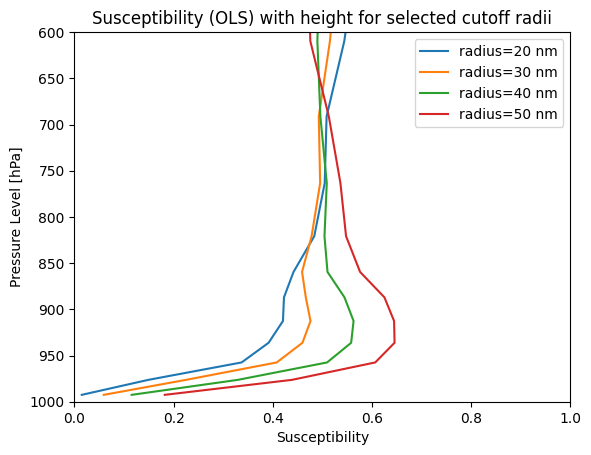

ODR


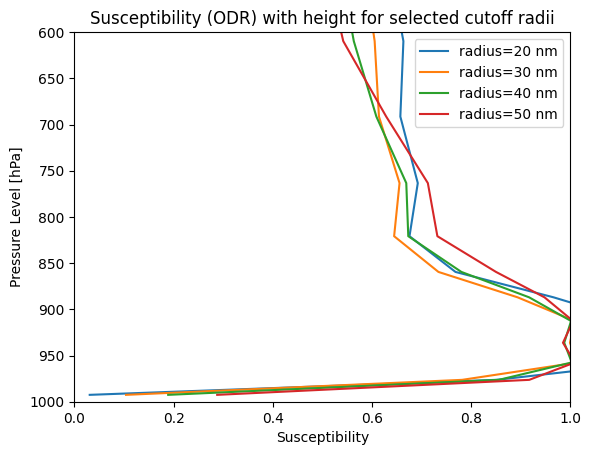

Deming


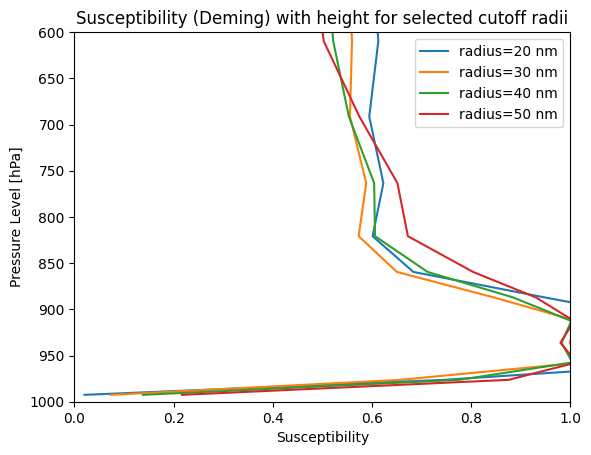

PCA


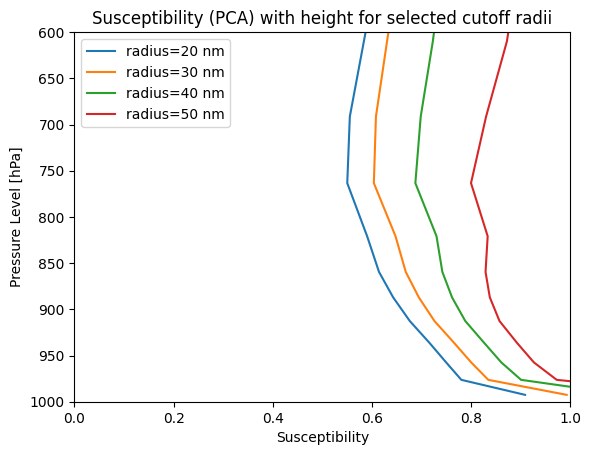

In [16]:
def PLOTSusc_by_Level(ds = Susceptibility_all, Fit = 'OLS', station = 'SMR-II'):
    radii_to_plot = [20, 30, 40, 50]
    for r in radii_to_plot:
        ds[f'{Fit} slope'].sel(radius=r, station = station).plot(
            y='lev', 
            yincrease=False, 
            ylim=[1000, 600],
            xlim = [0,1],
            label=f'radius={r} nm'
        )
    
    plt.legend()
    plt.xlabel("Susceptibility")
    plt.ylabel("Pressure Level [hPa]")
    plt.title(f"Susceptibility ({Fit}) with height for selected cutoff radii")
    plt.show()

FitType = ['OLS', 'ODR', 'Deming', 'PCA']
for fit in FitType:
    print(fit)
    PLOTSusc_by_Level(Susceptibility_all, Fit = fit, station = 'SMR-II')

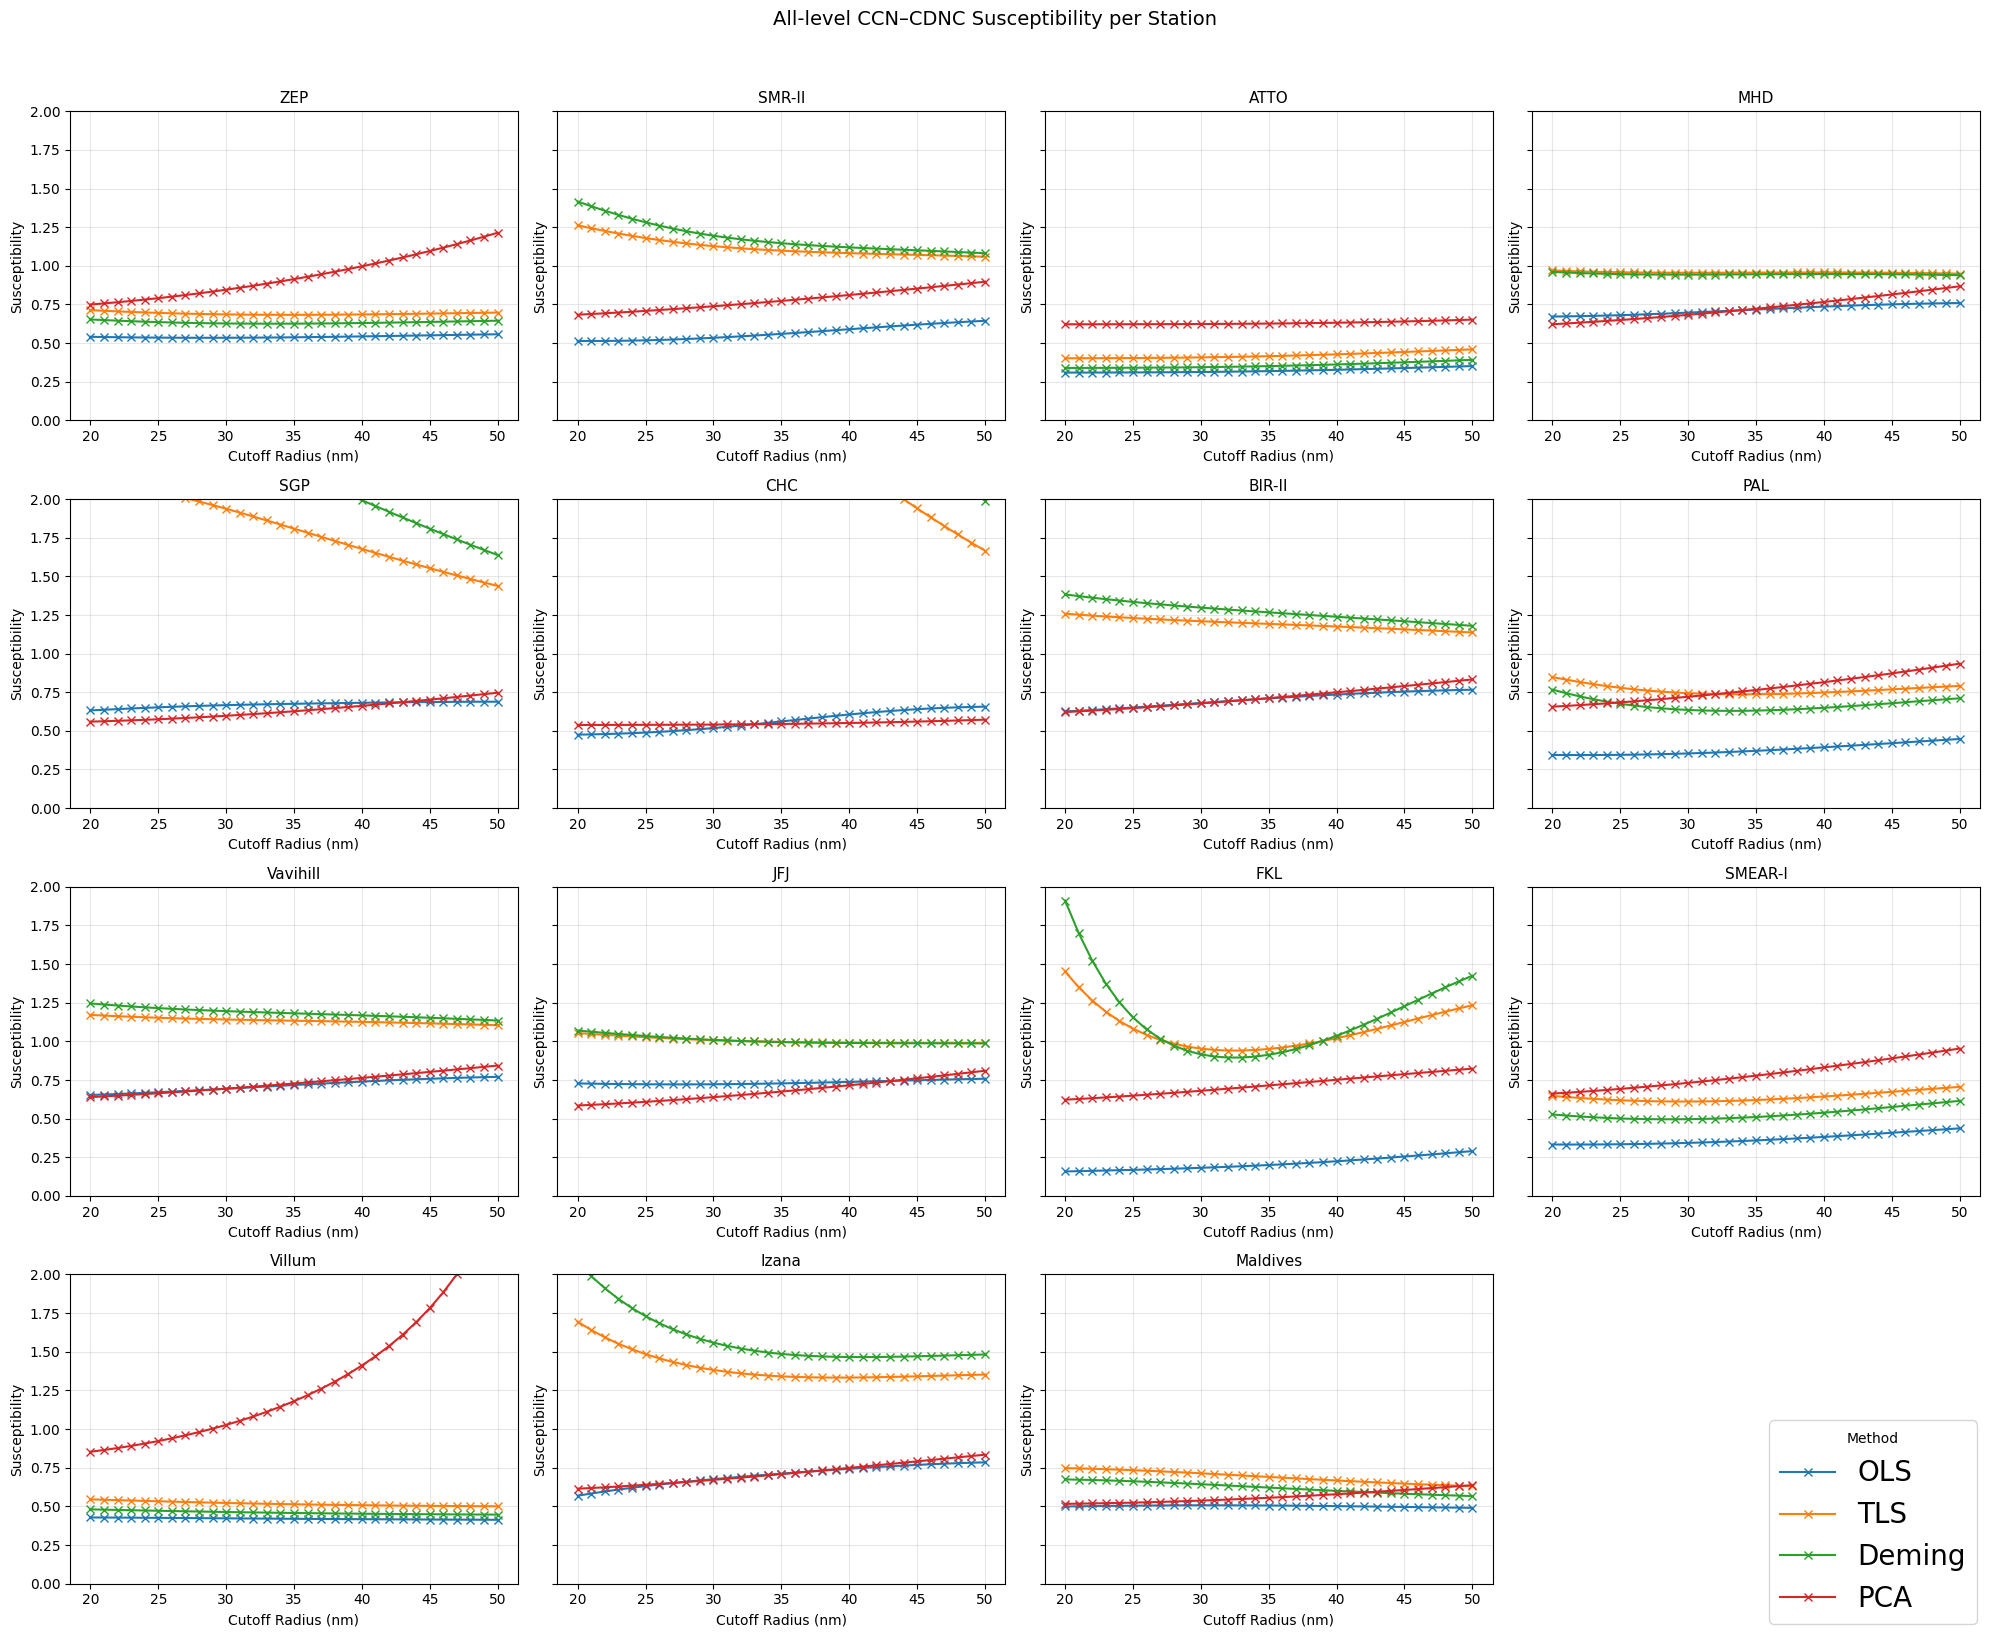

In [8]:
stations = Susceptibility_all.station.values
methods = ["OLS", "TLS", "Deming", "PCA"]

# Define number of columns and rows dynamically
ncols = 4
nrows = int(np.ceil(len(stations) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5 * ncols, 4 * nrows),
    sharey=True
)

axes = axes.flatten()

for i, station in enumerate(stations):
    ax = axes[i]
    for method in methods:
        var_name = f"All_Level_{method}_slope"
        if var_name in Susceptibility_all:
            Susceptibility_all[var_name].sel(station=station).plot(
                ax=ax, marker='x', label=method
            )
    ax.set_title(f"{station}", fontsize=11)
    ax.set_xlabel("Cutoff Radius (nm)")
    ax.set_ylabel("Susceptibility")
    ax.set_ylim(0, 2)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(len(stations), len(axes)):
    axes[j].set_visible(False)

# Add a global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Method", loc="lower right", fontsize=20)

fig.suptitle("All-level CCN–CDNC Susceptibility per Station", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [9]:
def plot_station_fits_from_dataset(Susceptibility_all, station, CCN_ds, Nor_ds, radius=35, methods=None):
    """
    Plot Nd vs CCN (log–log) with precomputed fits from Susceptibility_all.
    No refitting is done here.
    """
    if methods is None:
        methods = ["OLS", "TLS", "Deming", "PCA"]

    # --- Prepare data ---
    x = CCN_all['CCN'].sel(radius=radius, station = station).to_numpy().ravel()
    y = CCN_all["CDNC"].sel(station = station).to_numpy().ravel()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    fits = []

    # --- Get slopes/intercepts from dataset ---
    for method in methods:
        slope_var = f"All_Level_{method}_slope"
        intercept_var = f"All_Level_{method}_intercept"

        if slope_var in Susceptibility_all and intercept_var in Susceptibility_all:
            slope = Susceptibility_all[slope_var].sel(station=station, radius=radius).compute().item()
            intercept = Susceptibility_all[intercept_var].sel(station=station, radius=radius).compute().item()

            fits.append({
                "slope": slope,
                "intercept": intercept,
                "label": f"{method}: slope={slope:.2f}",
                "style": {
                    "OLS": "r-",
                    "TLS": "g--",
                    "Deming": "b-.",
                    "PCA": "m:",
                }.get(method, "k-")
            })

    # --- Plot all fits on a single hexbin plot ---
    fig, ax = Function.plot_hexbin_regression_multi(
        x, y,
        fits=fits,
        lims=(1, 1e4),
        title=f"{station}: CCN–CDNC Fits (radius={radius} nm)"
    )

    plt.tight_layout()
    return fig, ax

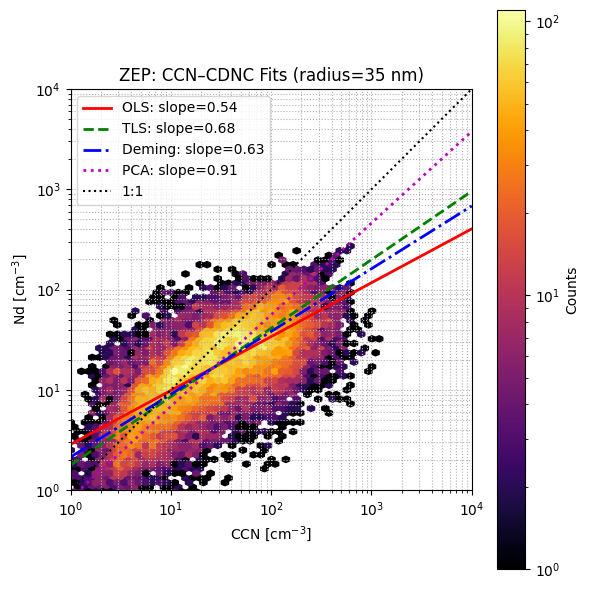

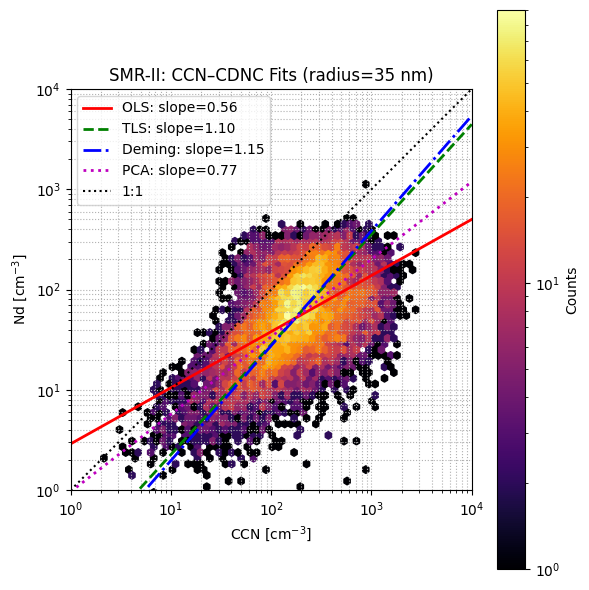

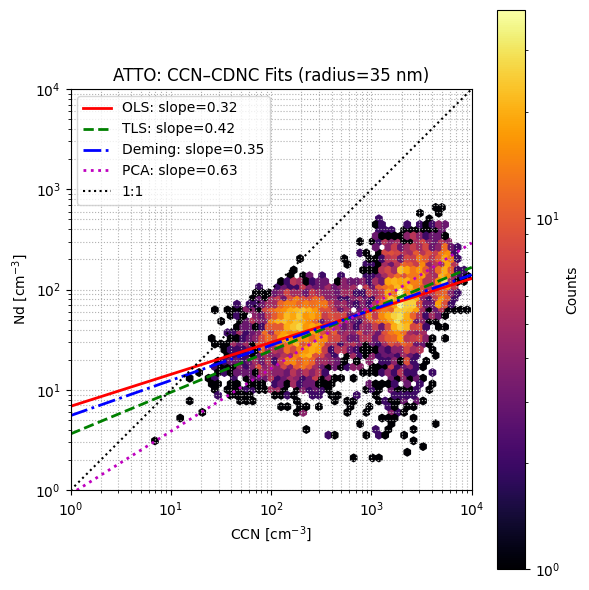

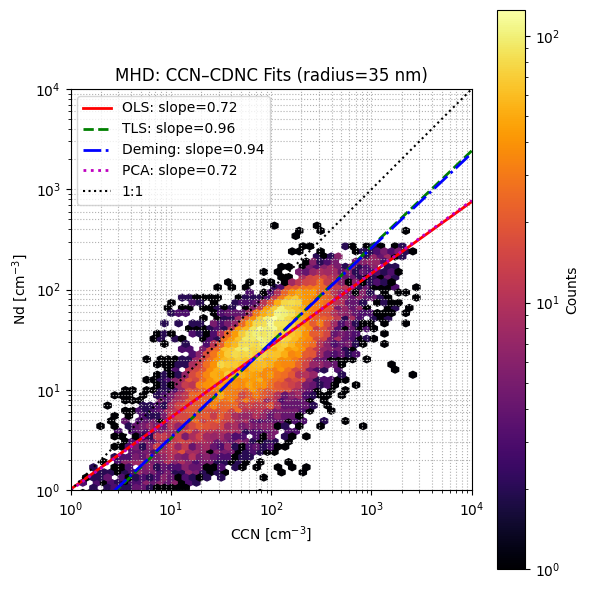

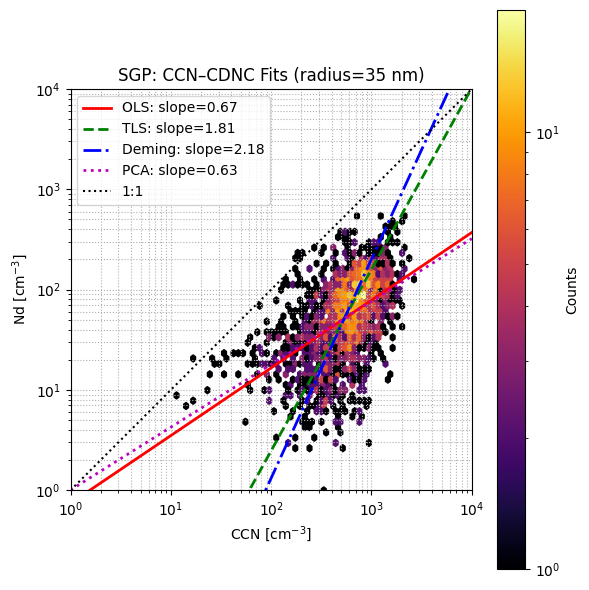

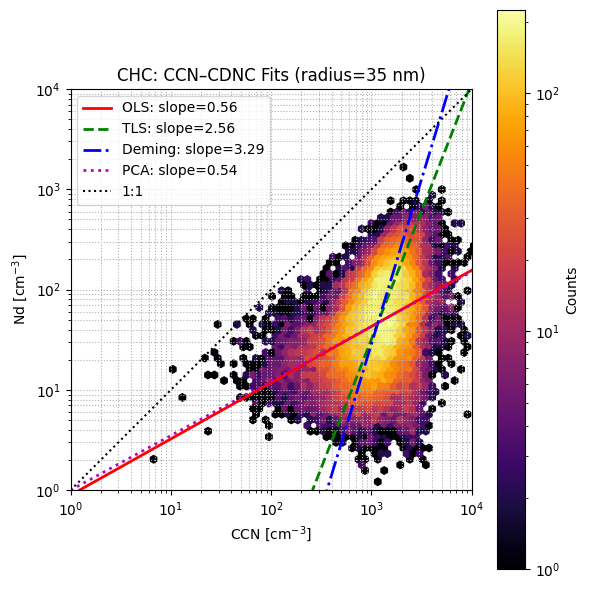

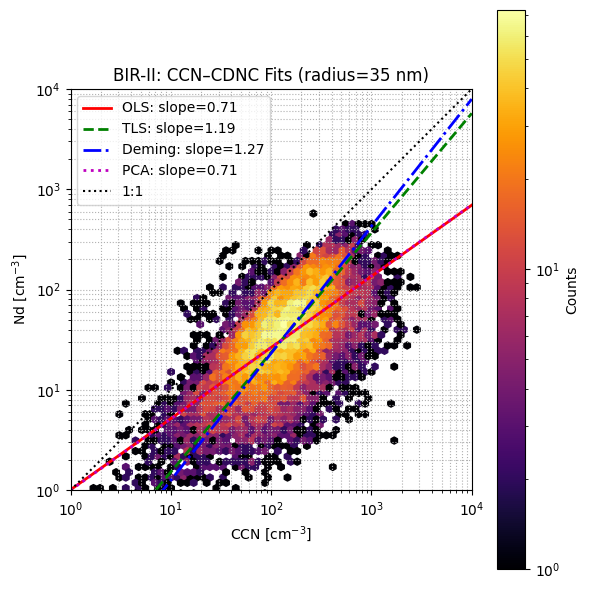

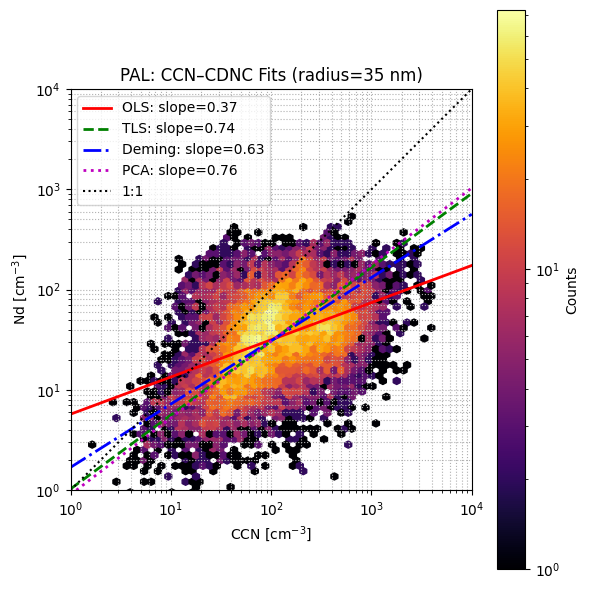

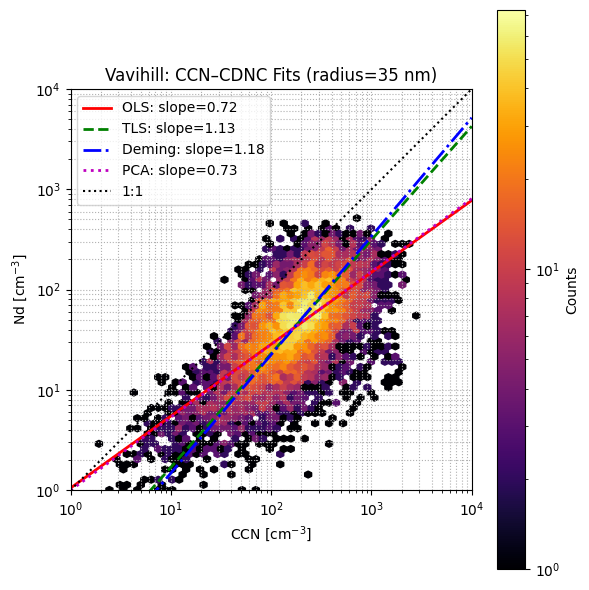

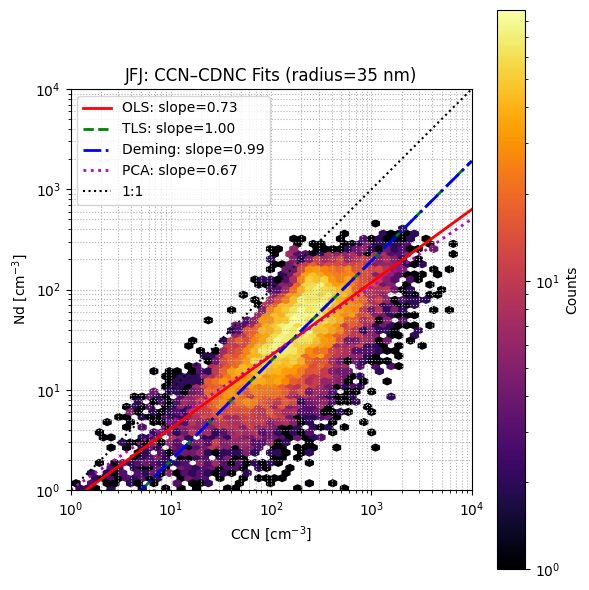

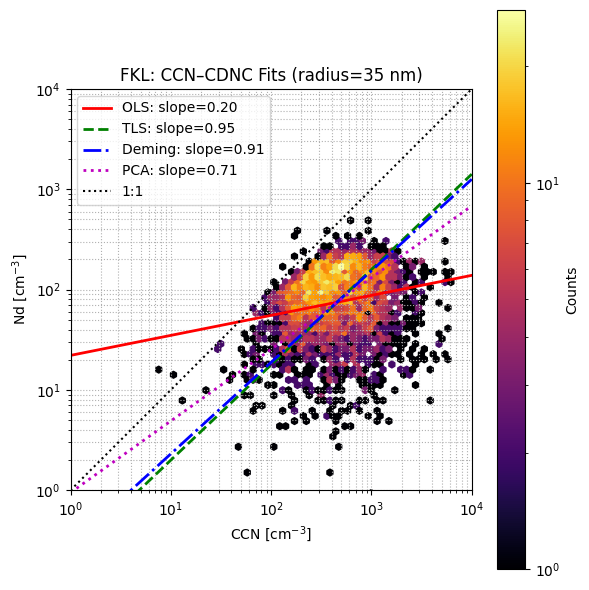

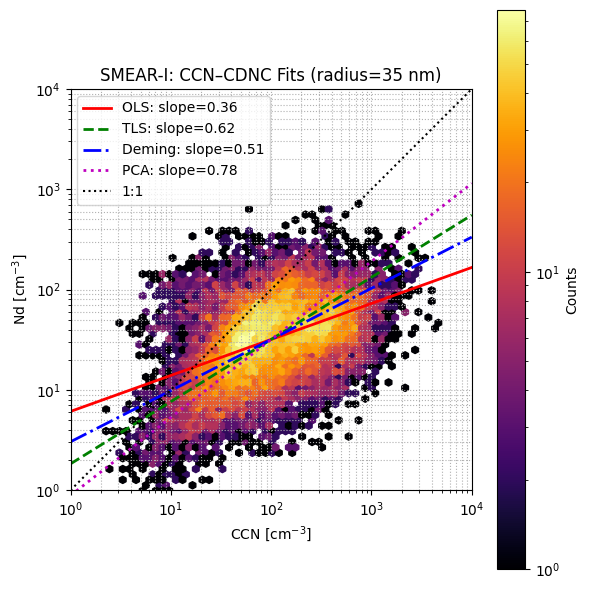

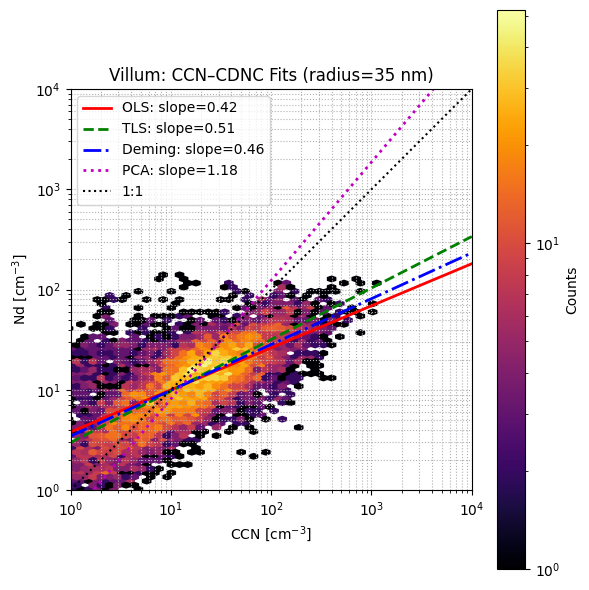

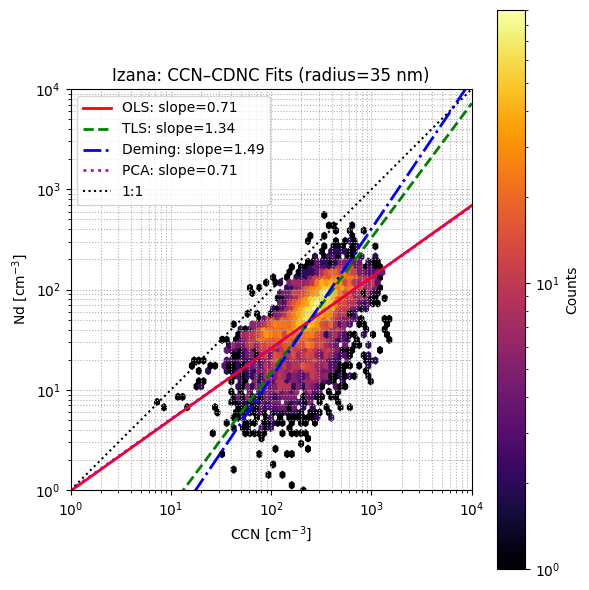

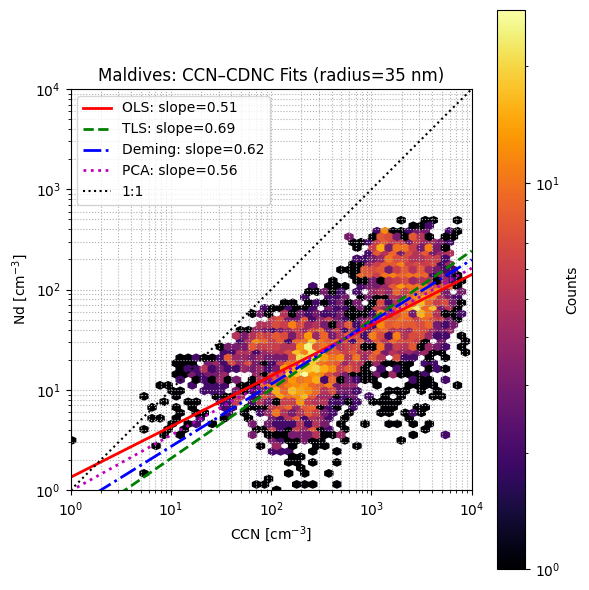

In [14]:
for station in stations:
    plot_station_fits_from_dataset(
        Susceptibility_all,
        station=station,
        CCN_ds=CCN_ds,
        Nor_ds=Nor_ds,
        radius=35
    )

In [ ]:
CCN_all